# TM10007 Machine Learning Group 10 Liver 

In [10]:
# Run this to use from colab environment
!pip install -q --upgrade git+https://github.com/jveenland/tm10007_ml.git

## Importing packages 


In [2]:
# General packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets as ds
import seaborn as sns

# Classifiers
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import svm


# Statistics
from sklearn import model_selection
from sklearn import metrics
from sklearn import svm
from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold, train_test_split, GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay, auc
from scipy.stats import zscore, shapiro
from sklearn.pipeline import Pipeline

## Data loading 

Below are functions to load the dataset of your choice. After that, it is all up to you to create and evaluate a classification method. Beware, there may be missing values in these datasets. Good luck!

In [2]:
from worcliver.load_data import load_data

# Load the data
data = load_data()

# Replace the labels with binary labels
data_binary = data.copy()
data_binary["label"] = data_binary["label"].map({"malignant": 1, "benign": 0})

# Print number of samples and columns
print(f"The number of samples: {len(data_binary.index)}")
print(f"The number of columns: {len(data_binary.columns)}")
print(f"The number of malignant samples: {sum(data_binary['label']==1)}")
print(f"The number of benign samples: {sum(data_binary['label']==0)}")

The number of samples: 186
The number of columns: 494
The number of malignant samples: 94
The number of benign samples: 92


## Data preprocessing

In [3]:
# Checking for duplicate samples
duplicate_samples = data_binary[data_binary.duplicated()]
if len(duplicate_samples) > 0:
    print(f"Number of duplicate rows: {len(duplicate_samples)}")
else:
    print("No duplicate sample found.")   
# Remove duplicate samples
data_cleaned = data_binary.drop_duplicates()

# Checking for duplicate features
duplicate_features = data_cleaned.columns[data_cleaned.columns.duplicated()]
if len(duplicate_features) > 0:
    print(f"Number of duplicate features: {len(duplicate_features)}")
    print("Duplicate feature names:")
    print(list(duplicate_features))
    # Remove duplicate features
    data_cleaned = data_cleaned.loc[:, ~data_cleaned.columns.duplicated()]   
else:
    print("No duplicate features found.")

# Checking for missing data
# Check for infinite values
print(f"Amount of infinite data: {data_cleaned.map(np.isinf).sum().sum()}")
# Check for missing values
print(f"Amount of missing data: {data_cleaned.isna().sum().sum()}")


No duplicate sample found.
No duplicate features found.
Amount of infinite data: 0
Amount of missing data: 0


## Data splitting


In [4]:
# Split the dataset in features and labels
X = data_cleaned.drop(columns=["label"])
y = data_cleaned["label"]

# Split the dataset in train and test part
X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Print the number of samples in the train and test set
print(f"The number of samples in the train set: {len(X_train.index)}")
print(f"The number of samples in the test set: {len(X_test.index)}")


The number of samples in the train set: 148
The number of samples in the test set: 38


## Scaling 
First check the distribution of the data, we check for normal and not normal distribution and we check the data on outliers

In [5]:
# Checking the distribution of the columns of the dataset and filling in missing values
alpha = 0.05
nd_columns_train = 0
nnd_columns_train = 0

for column in X_train:
    if X_train[column].min() != X_train[column].max():
        # Perform Shapiro-Wilk test for normality
        stat, p = shapiro(X_train[column].dropna())
        # Interpret the result
        if p > alpha:
            nd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the mean of the column
                X_train[column].fillna(X_train[column].mean(), inplace=True)
        else:
            nnd_columns_train += 1
            if X_train[column].isna().sum() > 0:
                # Fill missing values with the median of the column
                X_train[column].fillna(X_train[column].median(), inplace=True)
print(f"Number of normal distributed columns in the train set: {nd_columns_train}")
print(f"Number of non-normal distributed columns in the train set: {nnd_columns_train}")
    

Number of normal distributed columns in the train set: 53
Number of non-normal distributed columns in the train set: 423


In [6]:
# Calculating presence and number of outliers
columns_many_outliers_count = 0

for column in X_train:
    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)
    IQR = Q3 - Q1

    outliers = X_train[(X_train[column] < (Q1 - 1.5 * IQR)) | (X_train[column] > (Q3 + 1.5 * IQR))]
    outliers_count = outliers.shape[0]

    if outliers_count > 0.05 * X_train.shape[0]:
        columns_many_outliers_count += 1

perc_columns_many_outliers = (columns_many_outliers_count / len(X_train.columns)) * 100
print(f"Number of columns with many outliers: {columns_many_outliers_count}/{len(X_train.columns)} = {perc_columns_many_outliers:.2f}%")

Number of columns with many outliers: 166/493 = 33.67%


### Scaling the data

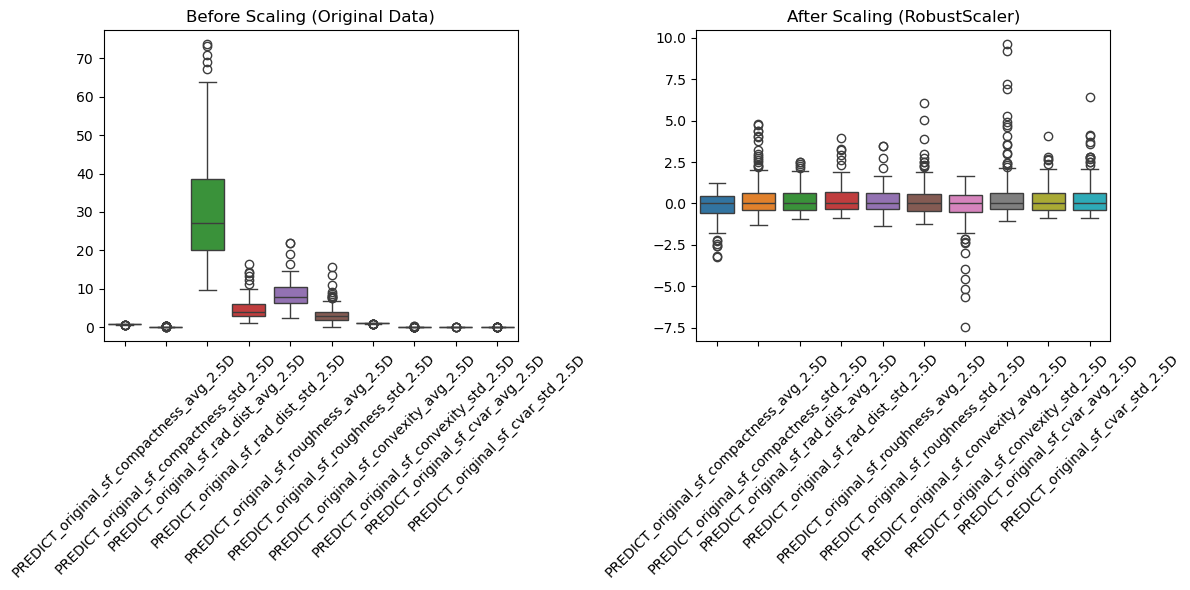

In [7]:
scaler = RobustScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled) 

features_to_plot = X_train.columns[:10] 
# Create a figure with two subplots
plt.figure(figsize=(12, 6))

# Plot original (unscaled) data
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train[features_to_plot])
plt.title("Before Scaling (Original Data)")
plt.xticks(rotation=45)

# Plot scaled data
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled[features_to_plot])
plt.title("After Scaling (RobustScaler)")
plt.xticks(rotation=45)

# Show the plot
plt.tight_layout()
plt.show()


### Feature selection

c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76  77  84  85  90  96  97 103 110 467 474 475 480 487 488] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Geselecteerde features na RFECV: ['PREDICT_original_sf_area_max_2.5D', 'PREDICT_original_sf_area_min_2.5D', 'PREDICT_original_hf_range', 'PREDICT_original_logf_kurtosis_sigma1', 'PREDICT_original_logf_peak_sigma1', 'PREDICT_original_logf_quartile_range_sigma1', 'PREDICT_original_tf_LBP_quartile_range_R8_P24', 'PREDICT_original_tf_Gabor_min_F0.05_A2.36', 'PREDICT_original_tf_Gabor_peak_F0.05_A2.36']
Aantal geselecteerde features: 9
Model accuraatheid (beste cross-val score): 0.8169274537695591


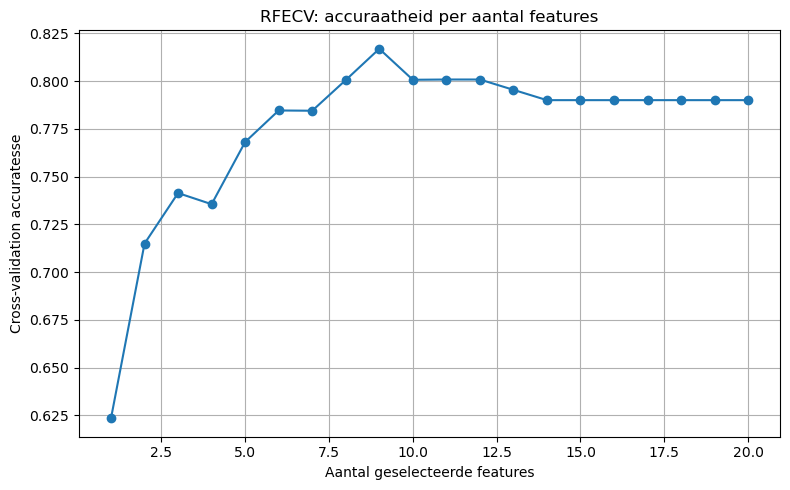

c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76  77  84  85  90  96  97 103 110 467 474 475 480 487 488] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76  77  84  85  90  96  97 103 110 467 474 475 480 487 488] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: User

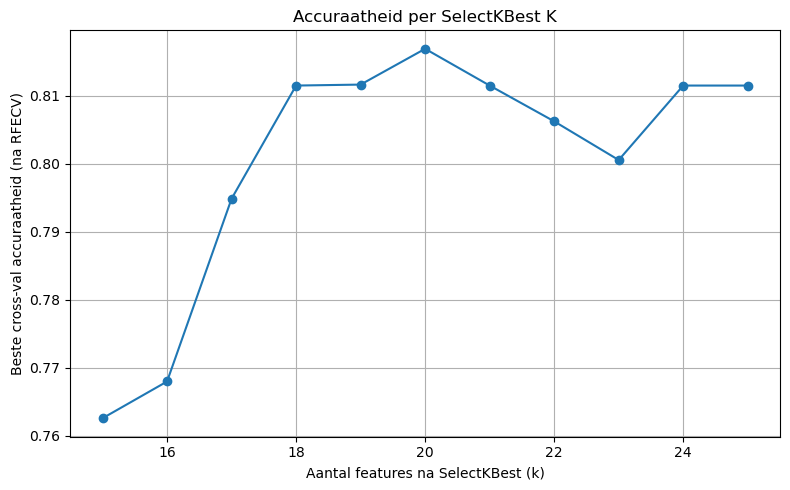

Accuraatheid van het model: 0.8333333333333334

Precision: 0.8387096774193549
Recall: 0.8297872340425532
F1-Score: 0.8342245989304813

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.84      0.83        92
           1       0.84      0.83      0.83        94

    accuracy                           0.83       186
   macro avg       0.83      0.83      0.83       186
weighted avg       0.83      0.83      0.83       186



In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, f_classif, RFECV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. Data inladen
df = pd.read_csv(r"worcliver\Liver_radiomicFeatures.csv")

# 2. X en y splitsen — pas 'label' aan als je kolom anders heet
X = df.drop(columns=["ID", "label"])  # alleen numerieke features
y = df["label"]

# 3. Zet de labels om van tekst naar numeriek
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)  # Zet 'benign' naar 0 en 'malignant' naar 1

# 4. Univariate selectie (top K features, hier K=20 als startpunt)
k = 20
univariate_selector = SelectKBest(score_func=f_classif, k=k)
X_selected = univariate_selector.fit_transform(X, y_encoded)
selected_feature_names = X.columns[univariate_selector.get_support()]

# 5. RFECV met logistic regression (L2 is standaard penalty)
model = LogisticRegression(max_iter=1000)
rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5), scoring="accuracy", n_jobs=-1)

# 6. Pipeline met scaling + RFECV
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", rfecv),
    ("classifier", LogisticRegression(max_iter=1000))
])

# 7. Fit pipeline op de eerder geselecteerde features
pipeline.fit(X_selected, y_encoded)

# 8. Resultaten
final_features = selected_feature_names[rfecv.support_]
print("Geselecteerde features na RFECV:", list(final_features))
print("Aantal geselecteerde features:", len(final_features))
print("Model accuraatheid (beste cross-val score):", rfecv.cv_results_['mean_test_score'][rfecv.n_features_ - 1])

# 9. Plot de gemiddelde cross-val scores per aantal features
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rfecv.cv_results_['mean_test_score']) + 1),
         rfecv.cv_results_['mean_test_score'],
         marker='o')
plt.xlabel("Aantal geselecteerde features")
plt.ylabel("Cross-validation accuratesse")
plt.title("RFECV: accuraatheid per aantal features")
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Plot accuraatheid vs K
k_values = [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]  # Pas dit aan als je meer resolutie wilt
accuracy_scores = []

for k in k_values:
    # 1. SelectKBest
    univariate_selector = SelectKBest(score_func=f_classif, k=k)
    X_selected = univariate_selector.fit_transform(X, y_encoded)
    selected_feature_names = X.columns[univariate_selector.get_support()]
    
    # 2. RFECV
    model = LogisticRegression(max_iter=1000)
    rfecv = RFECV(estimator=model, step=1, cv=StratifiedKFold(5), scoring="accuracy", n_jobs=-1)
    
    # 3. Pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("feature_selection", rfecv),
        ("classifier", LogisticRegression(max_iter=1000))
    ])
    
    # 4. Fit pipeline
    pipeline.fit(X_selected, y_encoded)
    
    # 5. Bewaar de beste score van RFECV
    score = rfecv.cv_results_['mean_test_score'][rfecv.n_features_ - 1]
    accuracy_scores.append(score)

# 11. Plot de accuraatheid per aantal features na SelectKBest
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("Aantal features na SelectKBest (k)")
plt.ylabel("Beste cross-val accuraatheid (na RFECV)")
plt.title("Accuraatheid per SelectKBest K")
plt.grid(True)
plt.tight_layout()
plt.show()

# 12. Resultaten - Precision, Recall, F1-score
y_pred = pipeline.predict(X_selected)

# Print de verschillende evaluatiestatistieken
print("Accuraatheid van het model:", accuracy_score(y_encoded, y_pred))
print("\nPrecision:", precision_score(y_encoded, y_pred))
print("Recall:", recall_score(y_encoded, y_pred))
print("F1-Score:", f1_score(y_encoded, y_pred))

# Daarnaast kun je ook de classification report afdrukken voor meer details
print("\nClassification Report:\n", classification_report(y_encoded, y_pred))


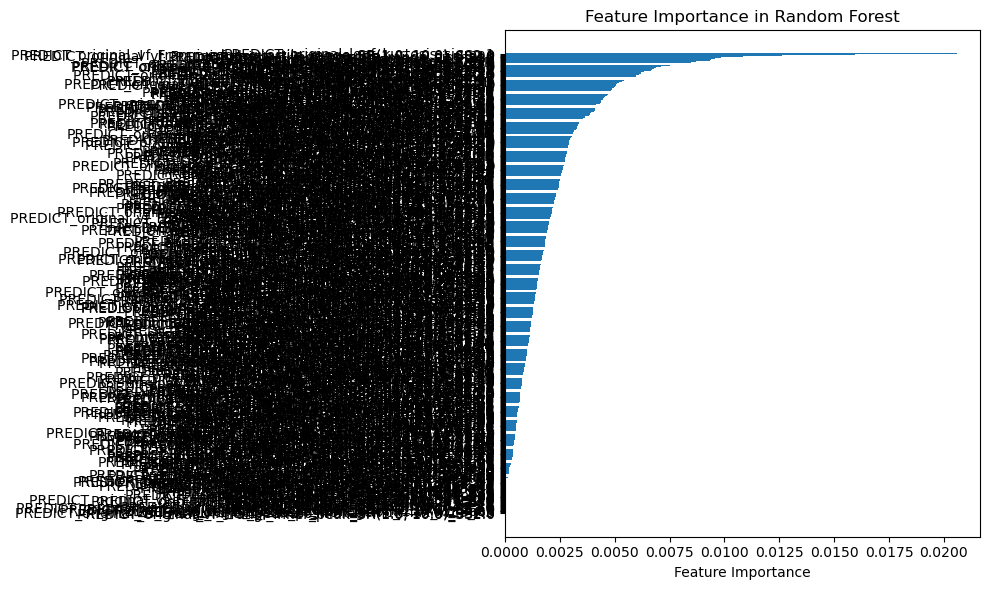

Feature importances: [0.00109736 0.00312629 0.00199902 0.00107159 0.00092006 0.0007992
 0.00086865 0.00413681 0.00328441 0.00038903 0.00187073 0.00252231
 0.00314688 0.00116306 0.00325163 0.00279555 0.00531773 0.0033358
 0.00870256 0.00179139 0.00228957 0.00052413 0.00265841 0.00272906
 0.0015862  0.00026888 0.00188476 0.00252218 0.00170506 0.00183865
 0.00181703 0.00129418 0.00292518 0.00506722 0.002525   0.00187786
 0.00091393 0.00595963 0.00677942 0.00595313 0.00409002 0.00078229
 0.005006   0.02060915 0.00520162 0.00352638 0.00244178 0.00311087
 0.00339375 0.00075374 0.00285355 0.0006461  0.00179197 0.00064978
 0.00498158 0.00134004 0.00566607 0.00084411 0.00114487 0.00270761
 0.00038611 0.00554064 0.00438677 0.00289442 0.00236673 0.00273178
 0.00143993 0.00211231 0.0093734  0.00689341 0.00119984 0.00231232
 0.00232191 0.00222597 0.01082703 0.00188921 0.         0.
 0.00163318 0.00470132 0.00671884 0.00825938 0.00134299 0.
 0.         0.         0.00353724 0.00090705 0.0014562  0.


In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# 1. Data inladen
df = pd.read_csv(r"worcliver\Liver_radiomicFeatures.csv")

# 2. X en y splitsen — pas 'label' aan als je kolom anders heet
X = df.drop(columns=["ID", "label"])  # alleen numerieke features
y = df["label"]

# 3. Pipeline zonder RFECV, alleen Random Forest
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),  # SVM en Random Forest werken beter met geschaalde data
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# 4. Fit de pipeline
pipeline_rf.fit(X, y)

# 5. Toegang tot feature importances
rf_model = pipeline_rf.named_steps['classifier']
feature_importances = rf_model.feature_importances_

# 6. Sorteer de features op basis van hun belang
sorted_idx = feature_importances.argsort()

# 7. Plot de feature importances
plt.figure(figsize=(10, 6))
plt.barh(X.columns[sorted_idx], feature_importances[sorted_idx])
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Random Forest")
plt.tight_layout()
plt.show()

# 8. Resultaten
print("Feature importances:", feature_importances)


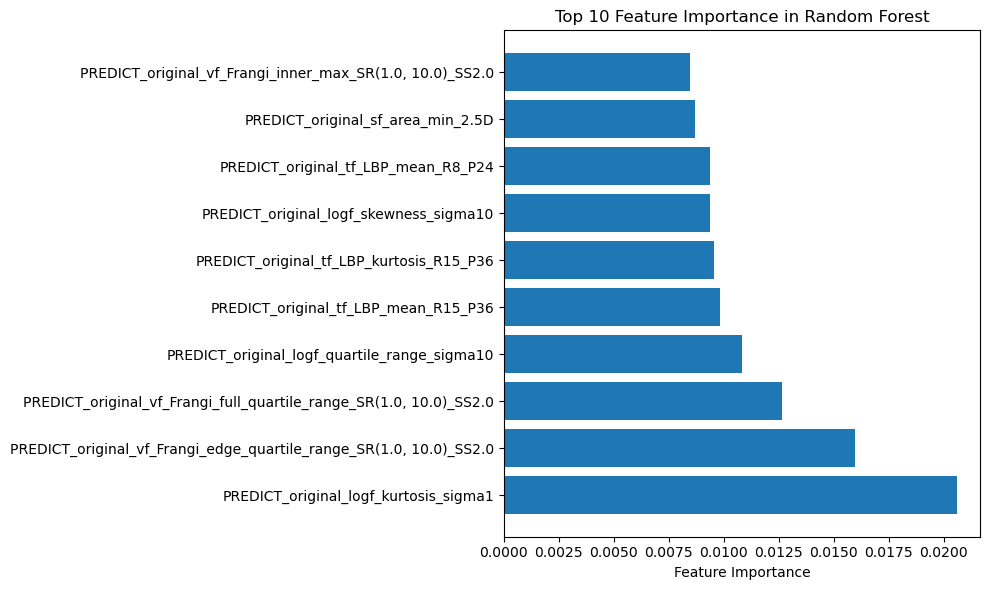

Accuraatheid van het model: 0.7368421052631579

Classification Report:
               precision    recall  f1-score   support

      benign       0.73      0.80      0.76        20
   malignant       0.75      0.67      0.71        18

    accuracy                           0.74        38
   macro avg       0.74      0.73      0.73        38
weighted avg       0.74      0.74      0.74        38


Confusion Matrix:
 [[16  4]
 [ 6 12]]


In [5]:
# 1. Sorteer de feature importances en krijg de top 10
top_n = 10  # je kunt dit veranderen naar 11, 12, etc.
top_n_idx = feature_importances.argsort()[-top_n:][::-1]  # Sorteer op belangrijkheid (aflopend)

# 2. De geselecteerde features
top_n_features = X.columns[top_n_idx]

# 3. Plot de top 10 features
plt.figure(figsize=(10, 6))
plt.barh(top_n_features, feature_importances[top_n_idx])
plt.xlabel("Feature Importance")
plt.title(f"Top {top_n} Feature Importance in Random Forest")
plt.tight_layout()
plt.show()

'''testen van prestatie RF met top ... features'''
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Data splitsen in training en test sets
X_train, X_test, y_train, y_test = train_test_split(X[top_n_features], y, test_size=0.2, random_state=42)

# 2. Random Forest model trainen op de top 10 geselecteerde features
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 3. Voorspellingen doen op de testset
y_pred = rf_model.predict(X_test)

# 4. Evaluatie van het model
print("Accuraatheid van het model:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: UserWarning: Features [ 76  77  84  85  90  96  97 103 110 467 474 475 480 487 488] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\caspe\miniconda3\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


Geselecteerde features door RFECV + SVM: ['PREDICT_original_sf_area_max_2.5D', 'PREDICT_original_sf_area_min_2.5D', 'PREDICT_original_hf_range', 'PREDICT_original_hf_quartile_range', 'PREDICT_original_logf_kurtosis_sigma1', 'PREDICT_original_logf_quartile_range_sigma1', 'PREDICT_original_tf_LBP_std_R3_P12', 'PREDICT_original_tf_LBP_quartile_range_R8_P24', 'PREDICT_original_tf_Gabor_min_F0.05_A2.36', 'PREDICT_original_tf_Gabor_peak_F0.05_A2.36']
Aantal geselecteerde features: 10
Model accuraatheid (beste cross-val score): 0.8059743954480796


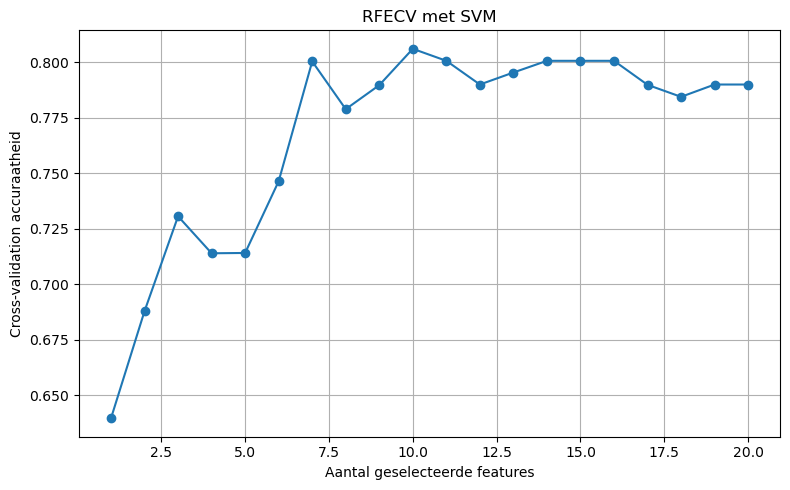

In [16]:
'''SVM'''

from sklearn.svm import SVC

# 1. SelectKBest (zelfde als voorheen)
k = 20
univariate_selector = SelectKBest(score_func=f_classif, k=k)
X_selected = univariate_selector.fit_transform(X, y)
selected_feature_names = X.columns[univariate_selector.get_support()]

# 2. RFECV met SVM
svm_model = SVC(kernel='linear', random_state=42)  # Gebruik lineaire kernel voor snelle evaluatie
rfecv_svm = RFECV(estimator=svm_model, step=1, cv=StratifiedKFold(5), scoring="accuracy", n_jobs=-1)

# 3. Pipeline met scaling (SVM heeft scaling nodig)
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),  # SVM werkt beter met geschaalde data
    ("feature_selection", rfecv_svm),
    ("classifier", SVC(kernel='linear', random_state=42))
])

# 4. Fitten
pipeline_svm.fit(X_selected, y)

# 5. Resultaten
final_features_svm = selected_feature_names[rfecv_svm.support_]
print("Geselecteerde features door RFECV + SVM:", list(final_features_svm))
print("Aantal geselecteerde features:", len(final_features_svm))
print("Model accuraatheid (beste cross-val score):", rfecv_svm.cv_results_['mean_test_score'][rfecv_svm.n_features_ - 1])

# 6. plotten van de resultaten
import matplotlib.pyplot as plt

# Plot de cross-validation score per aantal geselecteerde features (SVM)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(rfecv_svm.cv_results_['mean_test_score']) + 1),
         rfecv_svm.cv_results_['mean_test_score'],
         marker='o')
plt.xlabel("Aantal geselecteerde features")
plt.ylabel("Cross-validation accuraatheid")
plt.title("RFECV met SVM")
plt.grid(True)
plt.tight_layout()
plt.show()
